IMPRESSÃO DA CURVA NORMAL, MÉDIA =0, DESVIO PADRAO = 1


,0,1,2
count,400.000000,400.000000,400.000000
mean,-0.040218,-0.022107,-0.008813
std,1.029031,1.036020,0.960764
min,-1.782390,-1.743059,-1.449441
25%,-0.965865,-0.893722,-0.822428
50%,0.004151,-0.027575,-0.120006
75%,0.795264,0.934152,0.617120
max,1.721264,1.743700,2.794118


----- AVALIAÇÃO DO MODELO -----
Acurácia: 91.25%

Matriz de Confusão:
[[337   6]
 [ 29  28]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       343
           1       0.82      0.49      0.62        57

    accuracy                           0.91       400
   macro avg       0.87      0.74      0.78       400
weighted avg       0.91      0.91      0.90       400


----- PREVISÃO PARA NOVO CLIENTE -----
Dados do cliente: Renda: 120000, Idade: 46, Empréstimo: 8000
Probabilidade de pagar (Classe 0): 99.98%
Probabilidade de não pagar (Classe 1): 0.02%
Resultado: Crédito Aprovado (Bom pagador).


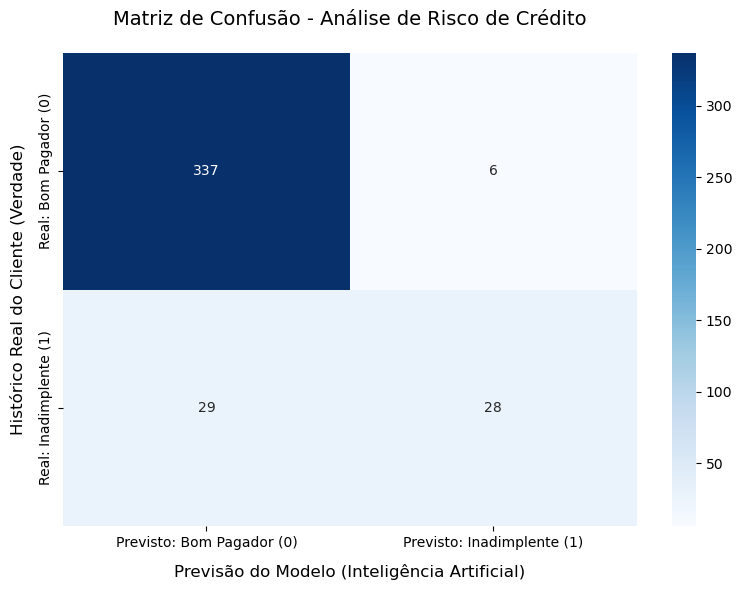

[[323  20]
 [ 20  37]]


In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# ==========================================
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# ==========================================

# Carregando o arquivo (ajuste o caminho se necessário)
df = pd.read_csv('credit_data.csv')

# Correção de pequenos detalhes nos nomes das colunas (removendo caracteres especiais)
df.columns = df.columns.str.replace('#', '').str.strip()

# Tratamento de valores inconsistentes ou nulos (comum no campo 'age' desse dataset)
# Se houver idades negativas, transformamos em positivo ou tratamos como nulo
df.loc[df['age'] < 0, 'age'] = np.nan

# Preenchendo valores nulos pela média da coluna
df['age'] = df['age'].fillna(df['age'].mean())

# Separando variáveis preditoras (X) e a variável alvo (y)
# Excluímos o 'clientid' pois é apenas um identificador
X = df[['income', 'age', 'loan']].values
y = df['cdefault'].values

# ==========================================
# 2. DIVISÃO DOS DADOS E PRÉ-PROCESSAMENTO
# ==========================================

# Divisão em Treino (80%) e Teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalização dos dados (Padronização)
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print('IMPRESSÃO DA CURVA NORMAL, MÉDIA =0, DESVIO PADRAO = 1')
f2 = pd.DataFrame(X_teste_scaled)
display(f2.describe())
# ==========================================
# 3. TREINAMENTO DO MODELO (NAIVE BAYES)
# ==========================================

modelo_nb = GaussianNB()
modelo_nb.fit(X_treino_scaled, y_treino) #pega-se o X_treino_scaled após X_treino ter passado por padronização

# Previsões no conjunto de teste
y_pred = modelo_nb.predict(X_teste_scaled) # PEGA O X_teste

# ==========================================
# 4. AVALIAÇÃO DO MODELO
# ==========================================

print("----- AVALIAÇÃO DO MODELO -----")
print(f"Acurácia: {accuracy_score(y_teste, y_pred) * 100:.2f}%")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred))

# ==========================================
# 5. PREVISÃO E PROBABILIDADE PARA UM NOVO DADO
# ==========================================

print("\n----- PREVISÃO PARA NOVO CLIENTE -----")

# Exemplo de novo cliente:
# Renda (income): 55.000 | Idade (age): 25 | Empréstimo solicitado (loan): 8.000
novo_cliente = np.array([[120000, 46, 8000]])

# Aplicar a MESMA escala (scaler) usada no treino
novo_cliente_scaled = scaler.transform(novo_cliente)

# Predição da classe (0 ou 1)
previsao = modelo_nb.predict(novo_cliente_scaled)

# Cálculo das probabilidades para cada classe
# predict_proba retorna um array: [probabilidade_de_ser_0, probabilidade_de_ser_1]
probabilidades = modelo_nb.predict_proba(novo_cliente_scaled)

print(f"Dados do cliente: Renda: {novo_cliente[0][0]}, Idade: {novo_cliente[0][1]}, Empréstimo: {novo_cliente[0][2]}")
print(f"Probabilidade de pagar (Classe 0): {probabilidades[0][0] * 100:.2f}%")
print(f"Probabilidade de não pagar (Classe 1): {probabilidades[0][1] * 100:.2f}%")

if previsao[0] == 1:
    print("Resultado: Crédito Recusado (Risco de Inadimplência).")
else:
    print("Resultado: Crédito Aprovado (Bom pagador).")
    

# EXPLICAÇÃO:
# Essa parte do código utiliza colchetes [ ] para acessar valores específicos de dentro de estruturas de dados chamadas Matrizes (ou arrays bidimensionais) e Vetores (arrays unidimensionais) criadas pelas bibliotecas numpy e scikit-learn.Para entender o que cada número faz, pense nos colchetes como um sistema de coordenadas: [linha][coluna].1. {novo_cliente[0][0]}, {novo_cliente[0][1]} e {novo_cliente[0][2]}Quando você criou o novo_cliente, 
# o código foi estruturado assim:Pythonnovo_cliente = np.array([[55000, 25, 8000]])
# Note que existem dois pares de colchetes [[ ... ]]. 
# Isso significa que criamos uma matriz (uma tabela) com 1 linha e 3 colunas.
# Como na programação a contagem sempre começa no zero:A primeira linha é a linha 0.A primeira coluna (Renda) é a coluna 0.A segunda coluna (Idade) é a coluna 1.
# A terceira coluna (Empréstimo) é a coluna 2.Portanto:novo_cliente[0][0]: Acessa a linha 0, coluna 0 $\rightarrow$ 55000novo_cliente[0][1]: Acessa a linha 0, coluna 1 $\rightarrow$ 25novo_cliente[0][2]: Acessa a linha 0, coluna 2 $\rightarrow$ 80002. {probabilidades[0][0]} e {probabilidades[0][1]}O método predict_proba calcula a probabilidade para cada cliente que você enviar.
# Como enviamos apenas 1 cliente, o resultado é uma matriz com 1 linha e 2 colunas: a primeira coluna guarda a chance de ser Classe 0 (pagar) e a segunda guarda a chance de ser Classe 1 (não pagar).O resultado gerado internamente pelo computador se parece com isso: [[0.85, 0.15]].probabilidades[0][0]: Vai na linha 0, coluna 0. 
# Pega a probabilidade de ser Classe 0 (ex: 0.85, que multiplicando por 100 vira 85.00%).probabilidades[0][1]: Vai na linha 0, coluna 1. Pega a probabilidade de ser Classe 1 (ex: 0.15, que multiplicando por 100 vira 15.00%).(O .2f que aparece logo depois apenas diz ao Python para formatar o número com 2 casas decimais).3. if previsao[0] == 1:O método predict devolve um vetor simples contendo as decisões finais do modelo para cada cliente testado.
# Como só passamos um cliente, a resposta é um vetor com um único elemento na posição zero.A variável previsao recebe algo como: [0] ou [1].previsao[0]: Acessa o primeiro (e único) elemento dessa lista para checar a decisão do algoritmo.
# Se esse valor na posição 0 for igual a 1, significa que o modelo previu "Inadimplência", disparando a mensagem de crédito recusado. Se for 0, o programa entra no else e aprova o crédito.

#GRAFICO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Gerar a matriz de confusão com os dados do seu modelo
# (Substitua y_teste e y_pred pelas variáveis do seu projeto)
cm = confusion_matrix(y_teste, y_pred)

# 2. Configurar o visual do gráfico
plt.figure(figsize=(8, 6))

# Criamos o mapa de calor usando o Seaborn
# annot=True coloca os números dentro dos quadrados
# fmt='d' garante que os números sejam exibidos como inteiros (e não notação científica)
# cmap='Blues' define a paleta de cores (tons de azul)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Previsto: Bom Pagador (0)', 'Previsto: Inadimplente (1)'],
            yticklabels=['Real: Bom Pagador (0)', 'Real: Inadimplente (1)'])

# 3. Adicionar títulos e rótulos para ficar claro para a diretoria
plt.title('Matriz de Confusão - Análise de Risco de Crédito', fontsize=14, pad=20)
plt.xlabel('Previsão do Modelo (Inteligência Artificial)', fontsize=12, labelpad=10)
plt.ylabel('Histórico Real do Cliente (Verdade)', fontsize=12, labelpad=10)

# Exibe o gráfico na tela
plt.tight_layout()
plt.show()

# 1. Pegar as probabilidades de inadimplência (Coluna 1)
probabilidades_teste = modelo_nb.predict_proba(X_teste_scaled)[:, 1]

# 2. Definir um limiar mais rigoroso (ex: 30% de chance de calote já bloqueia)
limiar_rigoroso = 0.30

# 3. Criar a nova previsão com base no novo limite de tolerância
y_pred_novo_limiar = (probabilidades_teste >= limiar_rigoroso).astype(int)

# Agora, gere a nova matriz de confusão para ver o "Risco Caro" despencar
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_teste, y_pred_novo_limiar))